EDA y Preprocesamiento para Brain Stroke CT Image Dataset
Dataset: Imágenes de tomografías cerebrales para detección de ictus
Objetivo: Preparar las imágenes para unirlas con un dataset tabular de ictus

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Para visualización mejorada
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [6]:
# =============================================================================
# DESCARGA DEL DATASET CON KAGGLEHUB
# =============================================================================

import kagglehub


print("=" * 80)
print("📥 DESCARGANDO DATASET DESDE KAGGLE")
print("=" * 80)

# Descargar dataset
path = kagglehub.dataset_download("afridirahman/brain-stroke-ct-image-dataset")
print(f"\n✅ Path to dataset files: {path}")

# Buscar la carpeta con las imágenes (normalmente está en un subdirectorio)
RUTA_DATASET = None

# El dataset puede estar directamente en path o en un subdirectorio
if os.path.exists(path):
    # Buscar estructura: path puede tener subdirectorios
    contenido = os.listdir(path)
    print(f"\n📁 Contenido del path descargado:")
    for item in contenido:
        print(f"   - {item}")
    
    # Buscar carpetas con imágenes (Normal, Stroke, etc.)
    for item in contenido:
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            # Verificar si tiene subdirectorios de clases
            subdirs = [d for d in os.listdir(item_path) if os.path.isdir(os.path.join(item_path, d))]
            if subdirs:
                RUTA_DATASET = item_path
                print(f"\n✅ Carpeta del dataset encontrada: {RUTA_DATASET}")
                print(f"   Clases detectadas: {subdirs}")
                break
    
    # Si no hay subdirectorios, usar path directamente
    if RUTA_DATASET is None:
        RUTA_DATASET = path
        print(f"\n✅ Usando path directamente: {RUTA_DATASET}")

else:
    print(f"❌ Error: No se encuentra el path {path}")

# Si no se pudo determinar automáticamente, pedir input manual
if RUTA_DATASET is None:
    RUTA_DATASET = input("\n📂 Ingresa la ruta del dataset manualmente: ").strip()
    RUTA_DATASET = RUTA_DATASET.replace('"', '').replace("'", "")

# Verificar que la ruta existe antes de continuar
if not os.path.exists(RUTA_DATASET):
    raise FileNotFoundError(f"❌ No se encuentra el dataset en: {RUTA_DATASET}")

print("\n" + "=" * 80)
print("📊 CARGANDO METADATA DEL DATASET DE IMÁGENES")
print("=" * 80)

# Cargar metadata
df_imagenes = cargar_metadata_imagenes(RUTA_DATASET)

print(f"\n✅ Total de imágenes cargadas: {len(df_imagenes)}")
print(f"\n📋 Primeras filas del dataset:")
print(df_imagenes.head())

print(f"\n🔍 Información del dataset:")
print(df_imagenes.info())

📥 DESCARGANDO DATASET DESDE KAGGLE


100%|██████████| 60.4M/60.4M [00:03<00:00, 20.2MB/s]

Extracting files...



✅ Path to dataset files: C:\Users\Administrator\.cache\kagglehub\datasets\afridirahman\brain-stroke-ct-image-dataset\versions\1

📁 Contenido del path descargado:
   - Brain_Data_Organised

✅ Carpeta del dataset encontrada: C:\Users\Administrator\.cache\kagglehub\datasets\afridirahman\brain-stroke-ct-image-dataset\versions\1\Brain_Data_Organised
   Clases detectadas: ['Normal', 'Stroke']

📊 CARGANDO METADATA DEL DATASET DE IMÁGENES

✅ Total de imágenes cargadas: 2501

📋 Primeras filas del dataset:
                                                ruta nombre_archivo   clase  \
0  C:\Users\Administrator\.cache\kagglehub\datase...    100 (1).jpg  Normal   
1  C:\Users\Administrator\.cache\kagglehub\datase...   100 (10).jpg  Normal   
2  C:\Users\Administrator\.cache\kagglehub\datase...   100 (11).jpg  Normal   
3  C:\Users\Administrator\.cache\kagglehub\datase...   100 (12).jpg  Normal   
4  C:\Users\Administrator\.cache\kagglehub\datase...   100 (13).jpg  Normal   

   ancho  alto formato


📈 ANÁLISIS EXPLORATORIO DE DATOS (EDA)

📊 Distribución de clases:
clase
Normal    1551
Stroke     950
Name: count, dtype: int64

Balance de clases:
  - Normal: 1551 imágenes (62.02%)
  - Stroke: 950 imágenes (37.98%)


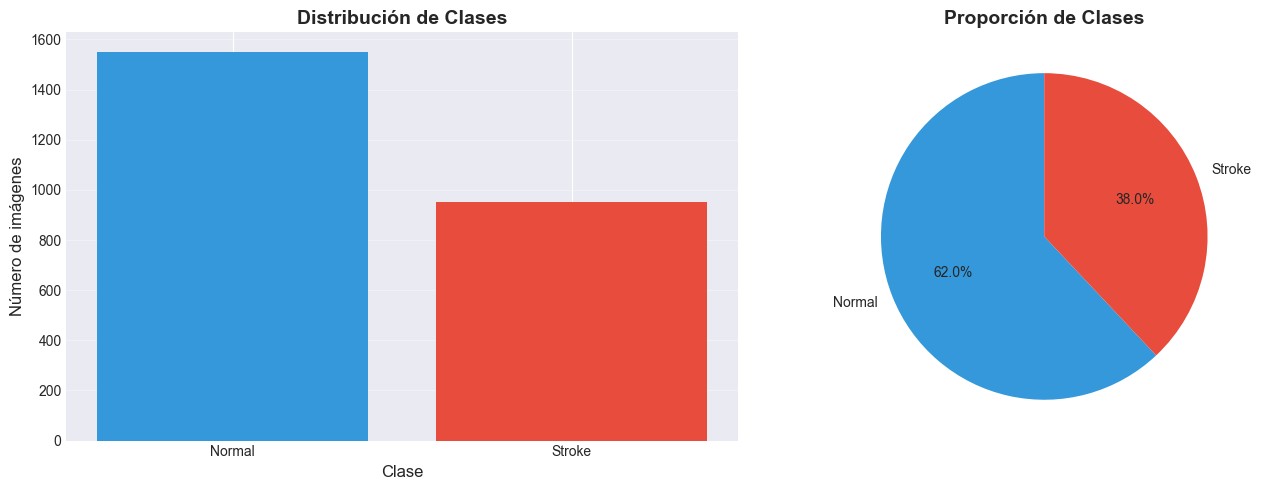


📏 Estadísticas de dimensiones de las imágenes:

Ancho:
count    2501.0
mean      650.0
std         0.0
min       650.0
25%       650.0
50%       650.0
75%       650.0
max       650.0
Name: ancho, dtype: float64

Alto:
count    2501.0
mean      650.0
std         0.0
min       650.0
25%       650.0
50%       650.0
75%       650.0
max       650.0
Name: alto, dtype: float64


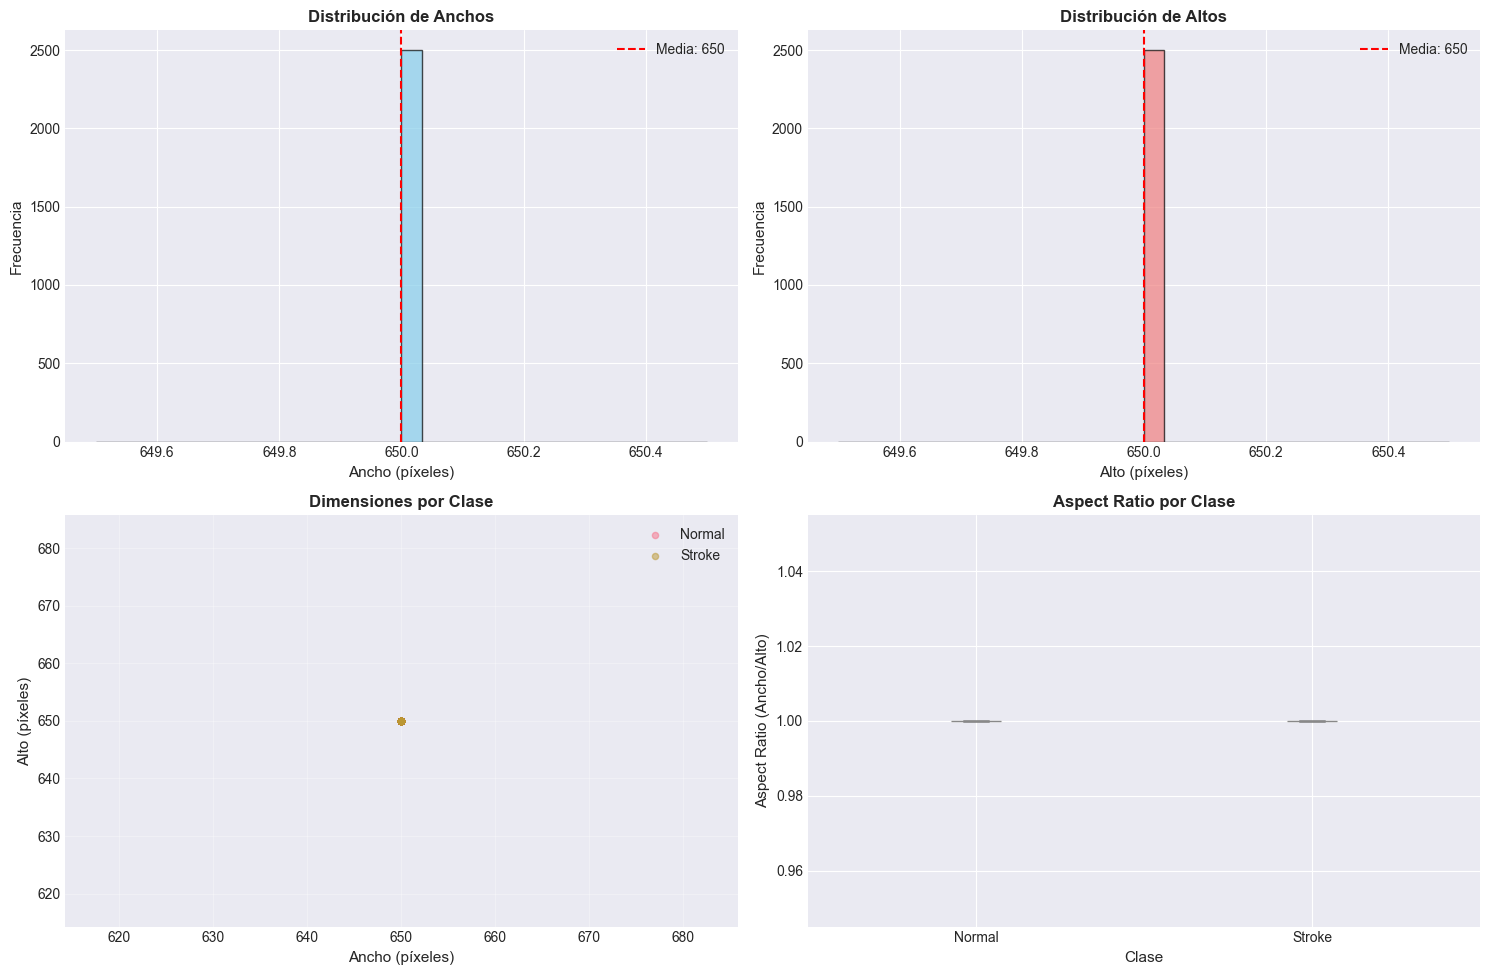


🎨 Formatos de imagen:
formato
JPEG    2501
Name: count, dtype: int64

🎨 Modos de color:
modo
L    2501
Name: count, dtype: int64

🖼️ Visualizando muestras de imágenes...


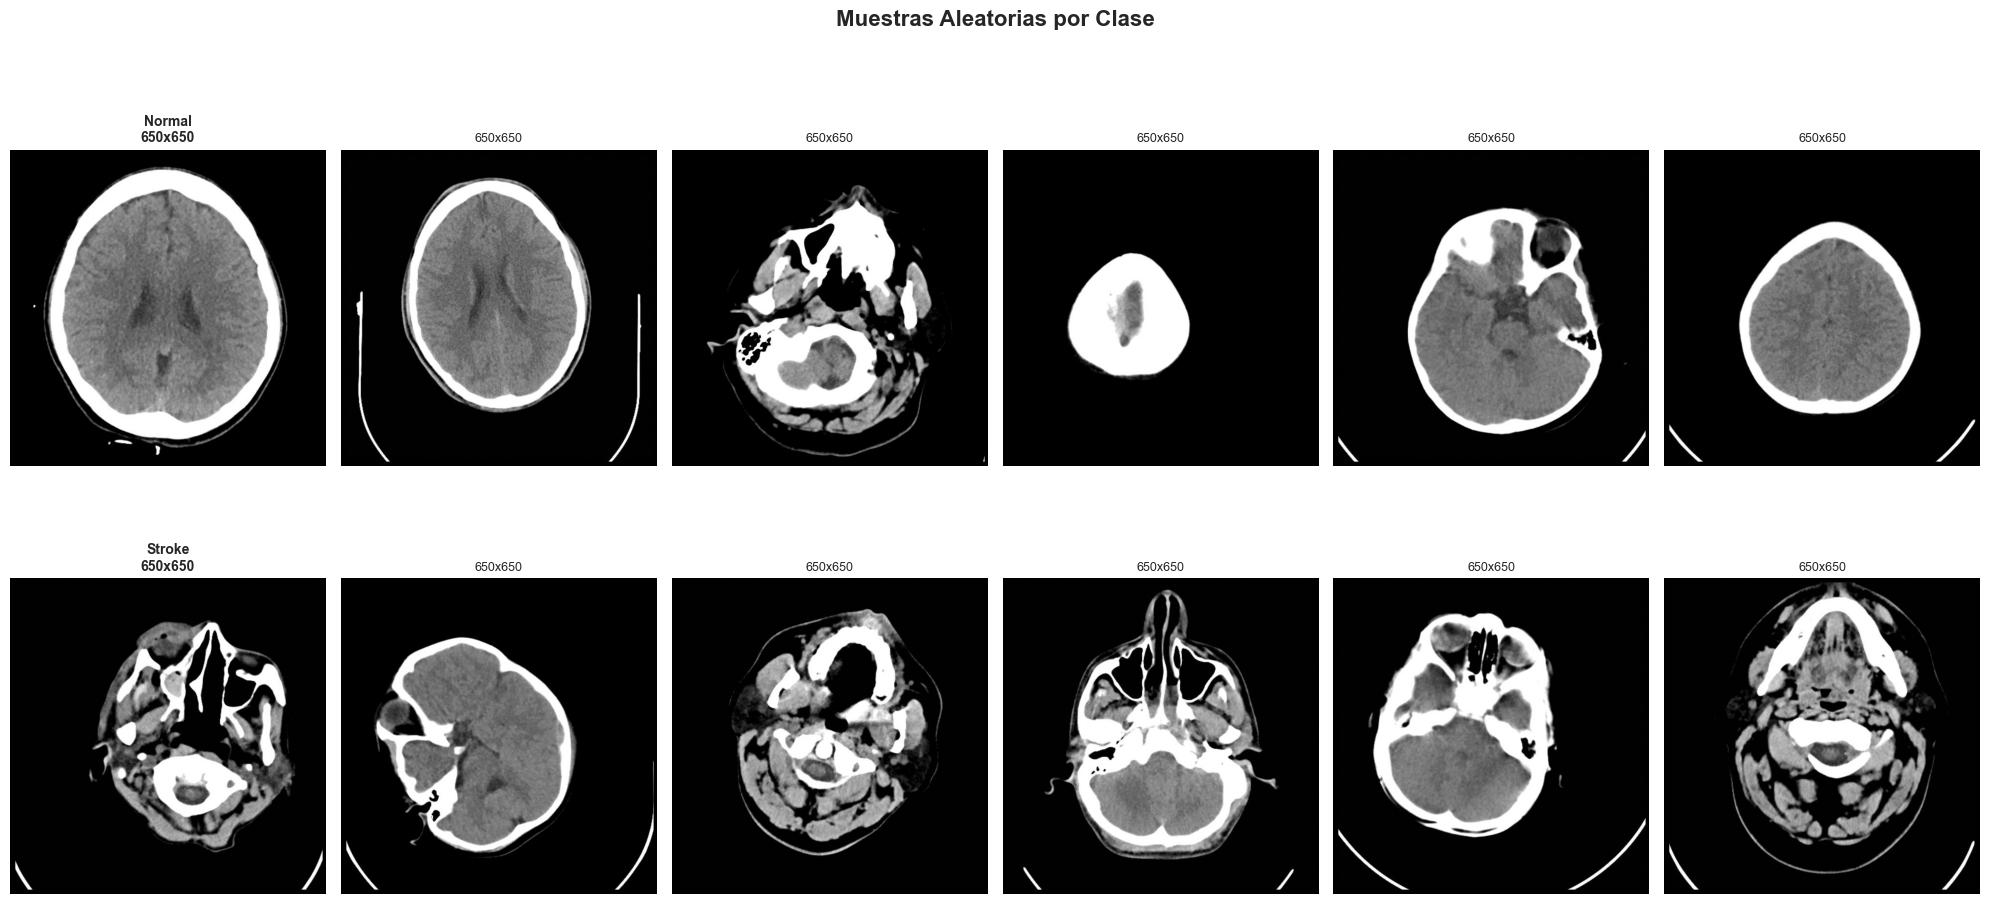


💡 Analizando intensidad de píxeles (esto puede tardar)...


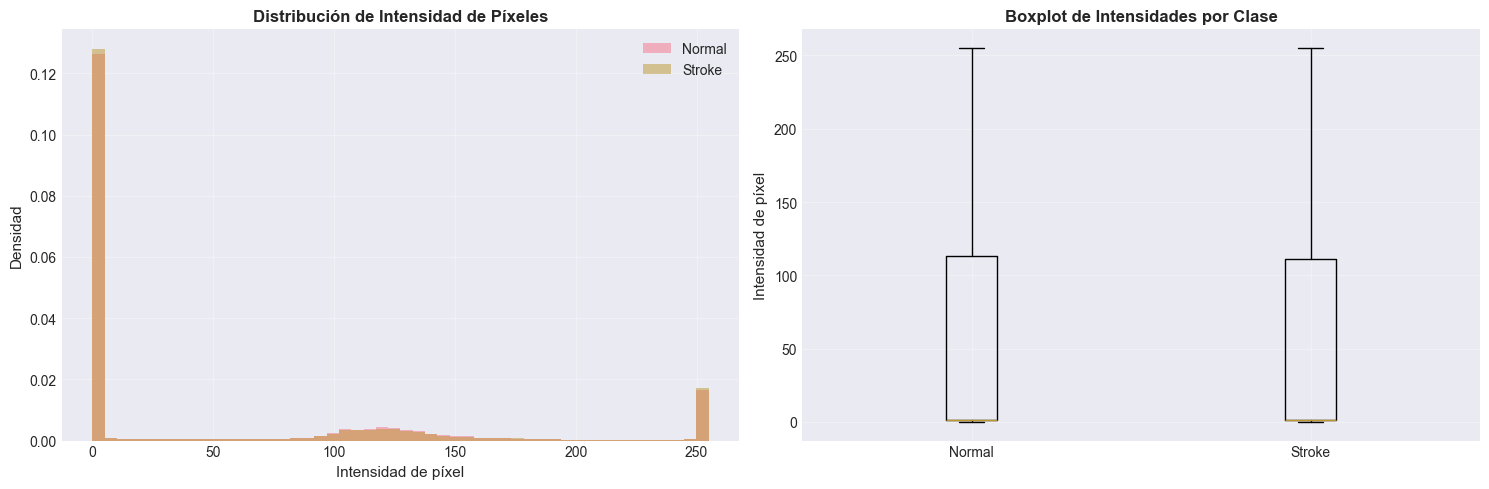

In [7]:
# =============================================================================
# 2. ANÁLISIS EXPLORATORIO (EDA)
# =============================================================================

print("\n" + "=" * 80)
print("📈 ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("=" * 80)

# 2.1 Distribución de clases
print("\n📊 Distribución de clases:")
distribucion_clases = df_imagenes['clase'].value_counts()
print(distribucion_clases)
print(f"\nBalance de clases:")
for clase, cantidad in distribucion_clases.items():
    porcentaje = (cantidad / len(df_imagenes)) * 100
    print(f"  - {clase}: {cantidad} imágenes ({porcentaje:.2f}%)")

# Visualización de distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(distribucion_clases.index, distribucion_clases.values, color=['#3498db', '#e74c3c'])
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Número de imágenes', fontsize=12)
axes[0].set_title('Distribución de Clases', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pie
axes[1].pie(distribucion_clases.values, labels=distribucion_clases.index, 
            autopct='%1.1f%%', startangle=90, colors=['#3498db', '#e74c3c'])
axes[1].set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=300, bbox_inches='tight')
plt.show()

# 2.2 Análisis de dimensiones
print("\n📏 Estadísticas de dimensiones de las imágenes:")
print("\nAncho:")
print(df_imagenes['ancho'].describe())
print("\nAlto:")
print(df_imagenes['alto'].describe())

# Visualización de dimensiones
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribución de anchos
axes[0, 0].hist(df_imagenes['ancho'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Ancho (píxeles)', fontsize=11)
axes[0, 0].set_ylabel('Frecuencia', fontsize=11)
axes[0, 0].set_title('Distribución de Anchos', fontsize=12, fontweight='bold')
axes[0, 0].axvline(df_imagenes['ancho'].mean(), color='red', linestyle='--', 
                   label=f'Media: {df_imagenes["ancho"].mean():.0f}')
axes[0, 0].legend()

# Distribución de altos
axes[0, 1].hist(df_imagenes['alto'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Alto (píxeles)', fontsize=11)
axes[0, 1].set_ylabel('Frecuencia', fontsize=11)
axes[0, 1].set_title('Distribución de Altos', fontsize=12, fontweight='bold')
axes[0, 1].axvline(df_imagenes['alto'].mean(), color='red', linestyle='--', 
                   label=f'Media: {df_imagenes["alto"].mean():.0f}')
axes[0, 1].legend()

# Scatter plot de dimensiones
for clase in df_imagenes['clase'].unique():
    df_clase = df_imagenes[df_imagenes['clase'] == clase]
    axes[1, 0].scatter(df_clase['ancho'], df_clase['alto'], alpha=0.5, label=clase, s=20)
axes[1, 0].set_xlabel('Ancho (píxeles)', fontsize=11)
axes[1, 0].set_ylabel('Alto (píxeles)', fontsize=11)
axes[1, 0].set_title('Dimensiones por Clase', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Boxplot de aspect ratio
df_imagenes['aspect_ratio'] = df_imagenes['ancho'] / df_imagenes['alto']
df_imagenes.boxplot(column='aspect_ratio', by='clase', ax=axes[1, 1])
axes[1, 1].set_xlabel('Clase', fontsize=11)
axes[1, 1].set_ylabel('Aspect Ratio (Ancho/Alto)', fontsize=11)
axes[1, 1].set_title('Aspect Ratio por Clase', fontsize=12, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.savefig('analisis_dimensiones.png', dpi=300, bbox_inches='tight')
plt.show()

# 2.3 Análisis de formatos y modos de color
print("\n🎨 Formatos de imagen:")
print(df_imagenes['formato'].value_counts())

print("\n🎨 Modos de color:")
print(df_imagenes['modo'].value_counts())


# 2.4 Visualización de muestras
def visualizar_muestras(df, n_muestras=8):
    """Visualiza muestras aleatorias de cada clase"""
    clases = df['clase'].unique()
    n_clases = len(clases)
    
    fig, axes = plt.subplots(n_clases, n_muestras, figsize=(20, 5*n_clases))
    if n_clases == 1:
        axes = axes.reshape(1, -1)
    
    for i, clase in enumerate(clases):
        df_clase = df[df['clase'] == clase]
        muestras = df_clase.sample(min(n_muestras, len(df_clase)))
        
        for j, (idx, row) in enumerate(muestras.iterrows()):
            img = Image.open(row['ruta'])
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(f'{clase}\n{row["ancho"]}x{row["alto"]}', 
                                    fontsize=10, fontweight='bold')
            else:
                axes[i, j].set_title(f'{row["ancho"]}x{row["alto"]}', fontsize=9)
    
    plt.suptitle('Muestras Aleatorias por Clase', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('muestras_imagenes.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n🖼️ Visualizando muestras de imágenes...")
visualizar_muestras(df_imagenes, n_muestras=6)


# 2.5 Análisis de intensidad de píxeles
def analizar_intensidad_pixeles(df, n_muestras=100):
    """Analiza la distribución de intensidad de píxeles"""
    print("\n💡 Analizando intensidad de píxeles (esto puede tardar)...")
    
    intensidades_por_clase = {}
    
    for clase in df['clase'].unique():
        df_clase = df[df['clase'] == clase]
        muestras = df_clase.sample(min(n_muestras, len(df_clase)))
        
        intensidades = []
        for _, row in muestras.iterrows():
            img = cv2.imread(row['ruta'], cv2.IMREAD_GRAYSCALE)
            if img is not None:
                intensidades.extend(img.flatten())
        
        intensidades_por_clase[clase] = intensidades
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Histograma
    for clase, intensidades in intensidades_por_clase.items():
        axes[0].hist(intensidades, bins=50, alpha=0.5, label=clase, density=True)
    axes[0].set_xlabel('Intensidad de píxel', fontsize=11)
    axes[0].set_ylabel('Densidad', fontsize=11)
    axes[0].set_title('Distribución de Intensidad de Píxeles', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Boxplot
    data_box = [intensidades_por_clase[clase] for clase in intensidades_por_clase.keys()]
    axes[1].boxplot(data_box, labels=intensidades_por_clase.keys())
    axes[1].set_ylabel('Intensidad de píxel', fontsize=11)
    axes[1].set_title('Boxplot de Intensidades por Clase', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('analisis_intensidad.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return intensidades_por_clase

intensidades = analizar_intensidad_pixeles(df_imagenes, n_muestras=50)


🔧 PREPROCESAMIENTO DE IMÁGENES

⚙️ Preprocesando imágenes a tamaño (224, 224)...
  Procesadas 100/2501 imágenes...
  Procesadas 200/2501 imágenes...
  Procesadas 300/2501 imágenes...
  Procesadas 400/2501 imágenes...
  Procesadas 500/2501 imágenes...
  Procesadas 600/2501 imágenes...
  Procesadas 700/2501 imágenes...
  Procesadas 800/2501 imágenes...
  Procesadas 900/2501 imágenes...
  Procesadas 1000/2501 imágenes...
  Procesadas 1100/2501 imágenes...
  Procesadas 1200/2501 imágenes...
  Procesadas 1300/2501 imágenes...
  Procesadas 1400/2501 imágenes...
  Procesadas 1500/2501 imágenes...
  Procesadas 1600/2501 imágenes...
  Procesadas 1700/2501 imágenes...
  Procesadas 1800/2501 imágenes...
  Procesadas 1900/2501 imágenes...
  Procesadas 2000/2501 imágenes...
  Procesadas 2100/2501 imágenes...
  Procesadas 2200/2501 imágenes...
  Procesadas 2300/2501 imágenes...
  Procesadas 2400/2501 imágenes...
  Procesadas 2500/2501 imágenes...

✅ Preprocesamiento completado: 2501 imágenes proces

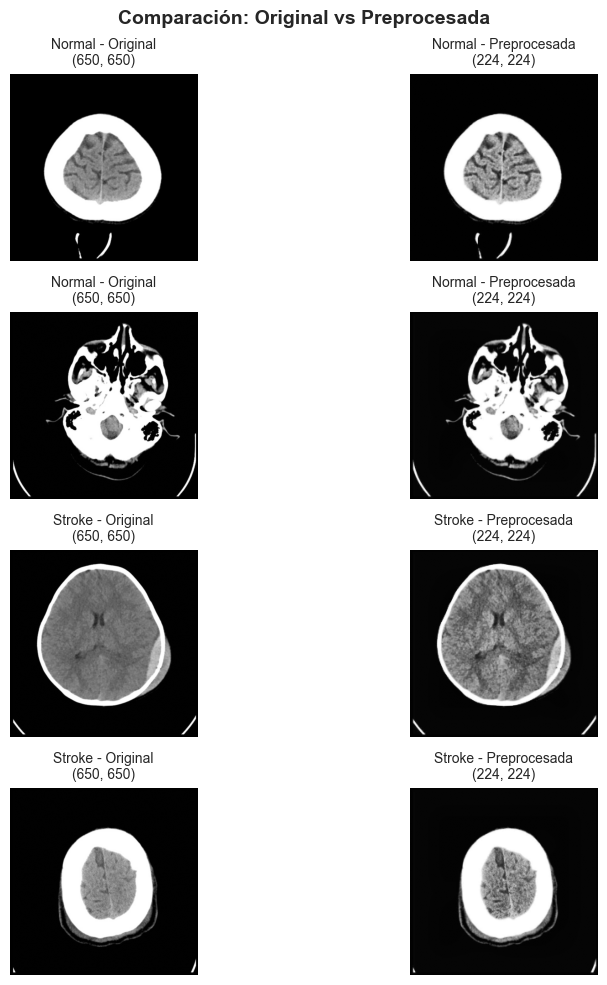

In [8]:
# =============================================================================
# 3. PREPROCESAMIENTO
# =============================================================================

print("\n" + "=" * 80)
print("🔧 PREPROCESAMIENTO DE IMÁGENES")
print("=" * 80)

# Parámetros de preprocesamiento
TAMAÑO_TARGET = (224, 224)  # Tamaño estándar para modelos pre-entrenados
NORMALIZAR = True

def preprocesar_imagen(ruta_imagen, tamaño=TAMAÑO_TARGET, normalizar=True):
    """
    Preprocesa una imagen:
    - Carga en escala de grises
    - Redimensiona
    - Normaliza (opcional)
    - Ecualización de histograma (opcional)
    """
    # Leer imagen
    img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        return None
    
    # Redimensionar
    img_resized = cv2.resize(img, tamaño, interpolation=cv2.INTER_AREA)
    
    # Ecualización de histograma CLAHE para mejorar contraste
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_enhanced = clahe.apply(img_resized)
    
    # Normalizar
    if normalizar:
        img_enhanced = img_enhanced.astype(np.float32) / 255.0
    
    return img_enhanced


# Preprocesar todas las imágenes y guardar características
print(f"\n⚙️ Preprocesando imágenes a tamaño {TAMAÑO_TARGET}...")

imagenes_procesadas = []
etiquetas = []

for idx, row in df_imagenes.iterrows():
    img_procesada = preprocesar_imagen(row['ruta'], TAMAÑO_TARGET, NORMALIZAR)
    
    if img_procesada is not None:
        imagenes_procesadas.append(img_procesada)
        etiquetas.append(row['clase'])
    
    if (idx + 1) % 100 == 0:
        print(f"  Procesadas {idx + 1}/{len(df_imagenes)} imágenes...")

print(f"\n✅ Preprocesamiento completado: {len(imagenes_procesadas)} imágenes procesadas")

# Convertir a arrays numpy
X = np.array(imagenes_procesadas)
y = np.array(etiquetas)

print(f"\n📦 Forma del array de imágenes: {X.shape}")
print(f"📦 Forma del array de etiquetas: {y.shape}")


# Visualizar efecto del preprocesamiento
def comparar_preprocesamiento(df, n_ejemplos=3):
    """Compara imágenes originales vs preprocesadas"""
    fig, axes = plt.subplots(n_ejemplos * 2, 2, figsize=(10, 5*n_ejemplos))
    
    for i, clase in enumerate(df['clase'].unique()):
        df_clase = df[df['clase'] == clase]
        muestras = df_clase.sample(n_ejemplos)
        
        for j, (idx, row) in enumerate(muestras.iterrows()):
            # Original
            img_original = cv2.imread(row['ruta'], cv2.IMREAD_GRAYSCALE)
            axes[i*n_ejemplos + j, 0].imshow(img_original, cmap='gray')
            axes[i*n_ejemplos + j, 0].set_title(f'{clase} - Original\n{img_original.shape}', 
                                               fontsize=10)
            axes[i*n_ejemplos + j, 0].axis('off')
            
            # Preprocesada
            img_procesada = preprocesar_imagen(row['ruta'], TAMAÑO_TARGET, False)
            axes[i*n_ejemplos + j, 1].imshow(img_procesada, cmap='gray')
            axes[i*n_ejemplos + j, 1].set_title(f'{clase} - Preprocesada\n{img_procesada.shape}', 
                                               fontsize=10)
            axes[i*n_ejemplos + j, 1].axis('off')
    
    plt.suptitle('Comparación: Original vs Preprocesada', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('comparacion_preprocesamiento.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n🔍 Comparando preprocesamiento...")
comparar_preprocesamiento(df_imagenes, n_ejemplos=2)

In [9]:
# =============================================================================
# 4. PREPARACIÓN PARA FUSIÓN CON DATASET TABULAR
# =============================================================================

print("\n" + "=" * 80)
print("🔗 PREPARACIÓN PARA FUSIÓN CON DATASET TABULAR")
print("=" * 80)

# Crear identificadores únicos para cada imagen
df_imagenes['image_id'] = [f"img_{i:05d}" for i in range(len(df_imagenes))]

# Codificar las clases
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_imagenes['clase_encoded'] = le.fit_transform(df_imagenes['clase'])

print("\n🏷️ Codificación de clases:")
for clase_orig, clase_enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {clase_orig} -> {clase_enc}")

# Calcular características adicionales para fusión
print("\n📊 Calculando características adicionales...")

def extraer_caracteristicas_imagen(img_array):
    """Extrae características estadísticas de la imagen"""
    return {
        'mean_intensity': np.mean(img_array),
        'std_intensity': np.std(img_array),
        'min_intensity': np.min(img_array),
        'max_intensity': np.max(img_array),
        'median_intensity': np.median(img_array),
        'contrast': np.std(img_array) / (np.mean(img_array) + 1e-7)
    }

caracteristicas_adicionales = []
for img in imagenes_procesadas:
    caracteristicas_adicionales.append(extraer_caracteristicas_imagen(img))

df_caracteristicas = pd.DataFrame(caracteristicas_adicionales)
df_imagenes_completo = pd.concat([df_imagenes, df_caracteristicas], axis=1)

print("\n📋 Dataset con características para fusión:")
print(df_imagenes_completo[['image_id', 'clase', 'clase_encoded', 
                            'mean_intensity', 'contrast']].head(10))



🔗 PREPARACIÓN PARA FUSIÓN CON DATASET TABULAR

🏷️ Codificación de clases:
  Normal -> 0
  Stroke -> 1

📊 Calculando características adicionales...

📋 Dataset con características para fusión:
    image_id   clase  clase_encoded  mean_intensity  contrast
0  img_00000  Normal              0        0.230542  1.458435
1  img_00001  Normal              0        0.252501  1.335877
2  img_00002  Normal              0        0.272073  1.279525
3  img_00003  Normal              0        0.285264  1.223808
4  img_00004  Normal              0        0.289162  1.177708
5  img_00005  Normal              0        0.289782  1.152496
6  img_00006  Normal              0        0.285446  1.131495
7  img_00007  Normal              0        0.281432  1.124738
8  img_00008  Normal              0        0.282485  1.126972
9  img_00009  Normal              0        0.282418  1.134614


In [10]:
# =============================================================================
# 4. PREPARACIÓN PARA FUSIÓN CON DATASET TABULAR
# =============================================================================

print("\n" + "=" * 80)
print("🔗 PREPARACIÓN PARA FUSIÓN CON DATASET TABULAR")
print("=" * 80)

# Crear identificadores únicos para cada imagen
df_imagenes['image_id'] = [f"img_{i:05d}" for i in range(len(df_imagenes))]

# Codificar las clases
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_imagenes['clase_encoded'] = le.fit_transform(df_imagenes['clase'])

print("\n🏷️ Codificación de clases:")
for clase_orig, clase_enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {clase_orig} -> {clase_enc}")

# Calcular características adicionales para fusión
print("\n📊 Calculando características adicionales...")

def extraer_caracteristicas_imagen(img_array):
    """Extrae características estadísticas de la imagen"""
    return {
        'mean_intensity': np.mean(img_array),
        'std_intensity': np.std(img_array),
        'min_intensity': np.min(img_array),
        'max_intensity': np.max(img_array),
        'median_intensity': np.median(img_array),
        'contrast': np.std(img_array) / (np.mean(img_array) + 1e-7)
    }

caracteristicas_adicionales = []
for img in imagenes_procesadas:
    caracteristicas_adicionales.append(extraer_caracteristicas_imagen(img))

df_caracteristicas = pd.DataFrame(caracteristicas_adicionales)
df_imagenes_completo = pd.concat([df_imagenes, df_caracteristicas], axis=1)

print("\n📋 Dataset con características para fusión:")
print(df_imagenes_completo[['image_id', 'clase', 'clase_encoded', 
                            'mean_intensity', 'contrast']].head(10))



🔗 PREPARACIÓN PARA FUSIÓN CON DATASET TABULAR

🏷️ Codificación de clases:
  Normal -> 0
  Stroke -> 1

📊 Calculando características adicionales...

📋 Dataset con características para fusión:
    image_id   clase  clase_encoded  mean_intensity  contrast
0  img_00000  Normal              0        0.230542  1.458435
1  img_00001  Normal              0        0.252501  1.335877
2  img_00002  Normal              0        0.272073  1.279525
3  img_00003  Normal              0        0.285264  1.223808
4  img_00004  Normal              0        0.289162  1.177708
5  img_00005  Normal              0        0.289782  1.152496
6  img_00006  Normal              0        0.285446  1.131495
7  img_00007  Normal              0        0.281432  1.124738
8  img_00008  Normal              0        0.282485  1.126972
9  img_00009  Normal              0        0.282418  1.134614


In [12]:
# =============================================================================
# 5. GUARDAR DATOS PROCESADOS Y VISUALIZACIONES
# =============================================================================

print("\n" + "=" * 80)
print("💾 GUARDANDO DATOS PROCESADOS")
print("=" * 80)

import os
from pathlib import Path

# Definir rutas de las carpetas (al mismo nivel que notebooks)
CARPETA_DATA = Path('..') / 'data'
CARPETA_REPORTS = Path('..') / 'reports'

# Crear carpetas si no existen
CARPETA_DATA.mkdir(parents=True, exist_ok=True)
CARPETA_REPORTS.mkdir(parents=True, exist_ok=True)

print(f"\n📁 Carpeta de datos: {CARPETA_DATA.absolute()}")
print(f"📁 Carpeta de reportes: {CARPETA_REPORTS.absolute()}")

# ============================================
# GUARDAR DATOS PREPROCESADOS EN /data
# ============================================

# Guardar arrays numpy de imágenes preprocesadas
np.save(CARPETA_DATA / 'X_imagenes_procesadas.npy', X)
np.save(CARPETA_DATA / 'y_etiquetas.npy', y)
print("\n✅ Arrays de imágenes guardados en /data:")
print(f"   - X_imagenes_procesadas.npy")
print(f"   - y_etiquetas.npy")

# Guardar DataFrame con metadata y características
df_imagenes_completo.to_csv(CARPETA_DATA / 'metadata_imagenes_completa.csv', index=False)
print("✅ Metadata guardada en /data:")
print(f"   - metadata_imagenes_completa.csv")

# Guardar label encoder
import pickle
with open(CARPETA_DATA / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("✅ Label encoder guardado en /data:")
print(f"   - label_encoder.pkl")

# ============================================
# GUARDAR VISUALIZACIONES EN /reports
# ============================================

# Nota: Las visualizaciones ya se guardaron durante el EDA
# Ahora las movemos a /reports si están en el directorio actual

import shutil

visualizaciones = [
    'distribucion_clases.png',
    'analisis_dimensiones.png',
    'muestras_imagenes.png',
    'analisis_intensidad.png',
    'comparacion_preprocesamiento.png'
]

print("\n✅ Moviendo visualizaciones a /reports:")
for viz in visualizaciones:
    if os.path.exists(viz):
        destino = CARPETA_REPORTS / viz
        shutil.move(viz, destino)
        print(f"   - {viz} → /reports/")
    else:
        print(f"   ⚠️  No se encontró: {viz}")





💾 GUARDANDO DATOS PROCESADOS

📁 Carpeta de datos: c:\Users\Administrator\Desktop\DS\project-ai-data-scientistG2\notebooks\..\data
📁 Carpeta de reportes: c:\Users\Administrator\Desktop\DS\project-ai-data-scientistG2\notebooks\..\reports

✅ Arrays de imágenes guardados en /data:
   - X_imagenes_procesadas.npy
   - y_etiquetas.npy
✅ Metadata guardada en /data:
   - metadata_imagenes_completa.csv
✅ Label encoder guardado en /data:
   - label_encoder.pkl

✅ Moviendo visualizaciones a /reports:
   - distribucion_clases.png → /reports/
   - analisis_dimensiones.png → /reports/
   - muestras_imagenes.png → /reports/
   - analisis_intensidad.png → /reports/
   - comparacion_preprocesamiento.png → /reports/


In [13]:
# =============================================================================
# 6. RESUMEN FINAL
# =============================================================================

print("\n" + "=" * 80)
print("📊 RESUMEN DEL PREPROCESAMIENTO")
print("=" * 80)

resumen = f"""
🔢 ESTADÍSTICAS GENERALES:
  - Total de imágenes: {len(df_imagenes)}
  - Clases: {list(df_imagenes['clase'].unique())}
  - Dimensión original promedio: {df_imagenes['ancho'].mean():.0f}x{df_imagenes['alto'].mean():.0f}
  - Dimensión tras preprocesamiento: {TAMAÑO_TARGET}
  
⚖️ BALANCE DE CLASES:
{distribucion_clases.to_string()}

📦 DATOS GUARDADOS:
  - X_imagenes_procesadas.npy: Shape {X.shape}
  - y_etiquetas.npy: Shape {y.shape}
  - metadata_imagenes_completa.csv: {len(df_imagenes_completo)} filas
  - label_encoder.pkl
  
🔗 CARACTERÍSTICAS PARA FUSIÓN:
  - image_id: Identificador único
  - clase_encoded: Etiqueta numérica
  - mean_intensity, std_intensity, contrast, etc.: Características estadísticas
  
✅ PRÓXIMOS PASOS:
  1. Cargar el dataset tabular de ictus
  2. Crear un identificador común entre ambos datasets
  3. Fusionar usando pandas merge() o join()
  4. Aplicar técnicas de ensemble o modelos multimodales
"""

print(resumen)
print("\n🎉 ¡PREPROCESAMIENTO COMPLETADO!")
print("=" * 80)


📊 RESUMEN DEL PREPROCESAMIENTO

🔢 ESTADÍSTICAS GENERALES:
  - Total de imágenes: 2501
  - Clases: ['Normal', 'Stroke']
  - Dimensión original promedio: 650x650
  - Dimensión tras preprocesamiento: (224, 224)

⚖️ BALANCE DE CLASES:
clase
Normal    1551
Stroke     950

📦 DATOS GUARDADOS:
  - X_imagenes_procesadas.npy: Shape (2501, 224, 224)
  - y_etiquetas.npy: Shape (2501,)
  - metadata_imagenes_completa.csv: 2501 filas
  - label_encoder.pkl

🔗 CARACTERÍSTICAS PARA FUSIÓN:
  - image_id: Identificador único
  - clase_encoded: Etiqueta numérica
  - mean_intensity, std_intensity, contrast, etc.: Características estadísticas

✅ PRÓXIMOS PASOS:
  1. Cargar el dataset tabular de ictus
  2. Crear un identificador común entre ambos datasets
  3. Fusionar usando pandas merge() o join()
  4. Aplicar técnicas de ensemble o modelos multimodales


🎉 ¡PREPROCESAMIENTO COMPLETADO!


In [14]:
# ============================================
# GUARDAR RESUMEN EN /reports
# ============================================

resumen = f"""
📊 RESUMEN DEL PREPROCESAMIENTO - BRAIN STROKE CT IMAGES
{"=" * 80}

🔢 ESTADÍSTICAS GENERALES:
  - Total de imágenes: {len(df_imagenes)}
  - Clases: {list(df_imagenes['clase'].unique())}
  - Dimensión original promedio: {df_imagenes['ancho'].mean():.0f}x{df_imagenes['alto'].mean():.0f}
  - Dimensión tras preprocesamiento: {TAMAÑO_TARGET}
  
⚖️ BALANCE DE CLASES:
{distribucion_clases.to_string()}

📦 DATOS GUARDADOS EN /data:
  - X_imagenes_procesadas.npy: Shape {X.shape}
  - y_etiquetas.npy: Shape {y.shape}
  - metadata_imagenes_completa.csv: {len(df_imagenes_completo)} filas
  - label_encoder.pkl
  
🖼️ VISUALIZACIONES EN /reports:
  - distribucion_clases.png
  - analisis_dimensiones.png
  - muestras_imagenes.png
  - analisis_intensidad.png
  - comparacion_preprocesamiento.png
  
🔗 CARACTERÍSTICAS PARA FUSIÓN:
  - image_id: Identificador único
  - clase_encoded: Etiqueta numérica
  - mean_intensity, std_intensity, contrast, etc.: Características estadísticas
  
✅ PRÓXIMOS PASOS:
  1. Cargar el dataset tabular de ictus
  2. Crear un identificador común entre ambos datasets
  3. Fusionar usando pandas merge() o join()
  4. Aplicar técnicas de ensemble o modelos multimodales

📂 ESTRUCTURA DE ARCHIVOS:
project/
├── data/
│   ├── X_imagenes_procesadas.npy
│   ├── y_etiquetas.npy
│   ├── metadata_imagenes_completa.csv
│   └── label_encoder.pkl
├── reports/
│   ├── distribucion_clases.png
│   ├── analisis_dimensiones.png
│   ├── muestras_imagenes.png
│   ├── analisis_intensidad.png
│   ├── comparacion_preprocesamiento.png
│   └── resumen_preprocesamiento.txt
└── notebooks/
    └── [tu notebook actual]
"""

# Guardar resumen en /reports
with open(CARPETA_REPORTS / 'resumen_preprocesamiento.txt', 'w', encoding='utf-8') as f:
    f.write(resumen)

print("\n✅ Resumen guardado en /reports:")
print(f"   - resumen_preprocesamiento.txt")

print("\n" + "=" * 80)
print("🎉 ¡TODOS LOS ARCHIVOS GUARDADOS EXITOSAMENTE!")
print("=" * 80)
print(resumen)



✅ Resumen guardado en /reports:
   - resumen_preprocesamiento.txt

🎉 ¡TODOS LOS ARCHIVOS GUARDADOS EXITOSAMENTE!

📊 RESUMEN DEL PREPROCESAMIENTO - BRAIN STROKE CT IMAGES

🔢 ESTADÍSTICAS GENERALES:
  - Total de imágenes: 2501
  - Clases: ['Normal', 'Stroke']
  - Dimensión original promedio: 650x650
  - Dimensión tras preprocesamiento: (224, 224)

⚖️ BALANCE DE CLASES:
clase
Normal    1551
Stroke     950

📦 DATOS GUARDADOS EN /data:
  - X_imagenes_procesadas.npy: Shape (2501, 224, 224)
  - y_etiquetas.npy: Shape (2501,)
  - metadata_imagenes_completa.csv: 2501 filas
  - label_encoder.pkl

🖼️ VISUALIZACIONES EN /reports:
  - distribucion_clases.png
  - analisis_dimensiones.png
  - muestras_imagenes.png
  - analisis_intensidad.png
  - comparacion_preprocesamiento.png

🔗 CARACTERÍSTICAS PARA FUSIÓN:
  - image_id: Identificador único
  - clase_encoded: Etiqueta numérica
  - mean_intensity, std_intensity, contrast, etc.: Características estadísticas

✅ PRÓXIMOS PASOS:
  1. Cargar el dataset 